# 21.10. Сопоставление изменений объёма камер сердца на исторической контрастной КТ

## Резюме

Для одной исторической серии КТ сопоставлены два способа выделения полостей сердца на 20 фазах реконструкции. Первый способ использует контуры, заданные по КТ исходной фазы, их перенос по деформации изображения и пороговое выделение контрастной крови. Второй способ — TotalSegmentator v2. Расчёт охватывает оба желудочка, оба предсердия, а также отдельные кандидатные маски наружной области сердца и ткани стенки.

**Основной результат:** различия между способами существенно зависят от камеры и фазы. Для левого желудочка изменения объёма на опорных фазах близки, тогда как для правого желудочка и предсердий обнаружены значительно большие расхождения. Просмотр показывает, что кандидатная разметка ещё недостаточно надёжно разделяет камеры и выходные тракты. Поэтому полученные различия характеризуют согласованность двух способов, но пока не измеряют ошибку TotalSegmentator.

Расчёт 20 фаз завершён; создание анатомически проверенного референса всего сердца остаётся незавершённым. Настоящий отчёт сохраняет как численный результат, так и причины, по которым его нельзя использовать для окончательной валидации.

## 1. Цель и место исследования

Задача состоит в проверке того, насколько результат TotalSegmentator воспроизводит изменение объёмов камер на протяжении реконструированного сердечного цикла. Для такой проверки нужен второй способ разметки с известными анатомическими границами и достаточной независимостью от проверяемого алгоритма. Совпадение объёмов само по себе не доказывает совпадение границ.

Предыдущий отчёт 21.09 описывает исправление частичных областей желудочков. Здесь рассматривается следующий этап: расширенные области четырёх камер и их динамика. Данные относятся к одной выбранной серии исторической КТ; результаты нельзя переносить на остальные исторические серии или на современные КТ добровольцев без отдельного сравнения.

## 2. Исходные данные и определения

Использованы 20 объёмов одной контрастной КТ с фазами от 0 до 95% через 5%. Размер массива каждой фазы — 512 × 512 × 103, шаг отсчётов — приблизительно 0,473 × 0,473 × 2,5 мм. Указанная в исходных метаданных толщина среза составляет 5 мм. Шаг 2,5 мм не означает независимое пространственное разрешение 2,5 мм: соседние реконструированные срезы перекрываются. Пересчёт в изотропные воксели не восстановит отсутствующие детали клапанов и тонких стенок.

Обозначения: ЛЖ — левый желудочек, ПЖ — правый желудочек, ЛП — левое предсердие, ПП — правое предсердие. Под объёмом камеры в этом отчёте понимается объём выделенной области её полости. Сумма четырёх полостей исключает миокард и не равна объёму всего сердца. Наружная область сердца и ткань его стенки рассматриваются отдельно.

Процент фазы задаёт положение в последовательности реконструкции. Фаза 0% выбрана как начало отсчёта изменений, а не как доказанная конечная диастола. Конечная диастола и конечная систола независимо не установлены; ударный объём и фракция выброса здесь не рассчитываются.

| Вход или результат | Происхождение | Доказательный статус |
|---|---|---|
| Изображения и пространственная геометрия КТ | Исходная реконструкция, преобразованная в NIfTI | Измерительные данные и их технические метаданные |
| Контуры исходной фазы | Заданы агентом по разрешённому просмотру обезличенной КТ | Кандидатная анатомическая разметка; экспертно не принята |
| Контуры других фаз | Вычислены по деформации КТ и локальному порогу яркости | Результат алгоритма, без независимой ручной обводки каждой фазы |
| Маски TotalSegmentator | Версия 2.18.0; задачи общего сердца и камер высокого разрешения | Автоматическая сегментация той же серии |
| Разности объёмов двух способов | Подсчёт вокселей на совпадающих физических сетках | Воспроизводимое расхождение методов; истинная ошибка неизвестна |

## 3. Способы сегментации и введённые допущения

### 3.1. Контуры исходной фазы

Области желудочков были расширены относительно частичных масок отчёта 21.09; дополнительно заданы области предсердий. Опорные контуры интерполированы между срезами. Разделение желудочков и предсердий включает приближённые плоскости клапанных границ. В области правых камер разделяющее правило действует в пересечении их поисковых областей, чтобы не отсечь весь передний выходной тракт одним глобальным сечением.

Границы клапанов, переходы к магистральным сосудам, устья вен и полнота включения ушек предсердий остаются неопределёнными. В частности, верхняя граница кандидатного ПЖ в исходной фазе достигает среза 35, тогда как автоматическая маска продолжается выше. Это различие требует просмотра клапанной области в нескольких плоскостях. Нельзя заранее считать дополнительную область TotalSegmentator сосудом, ошибочно включённым в желудочек.

### 3.2. Перенос на остальные фазы

Изображение каждой целевой фазы совмещено с исходной КТ посредством B-сплайнового поля деформации. При оценке преобразования использованы только изображения КТ; маски TotalSegmentator не участвовали. Вычисление выполнено в ограниченной области сердца на сетке приблизительно 2 × 2 × 2,5 мм, с расстоянием между управляющими узлами 20 мм, тремя уровнями разрешения и лимитом 40 итераций на уровень. Критерий совмещения — взаимная информация.

Преобразование переносит исходные поисковые области на целевую КТ. В каждой области выделяются воксели с интенсивностью не ниже 190 HU; сохраняется крупнейшая компонента с шестисвязным соседством. Дополнительно рассчитаны пороги 170 и 210 HU. Это выбранные вычислительные сценарии, а не литературные границы нормальной плотности крови и не доверительный интервал ошибки. Одинаковый порог не гарантирует одинаковой анатомической полноты при изменении контраста и частичного объёма.

Отдельно сохранён перенос готовых бинарных масок без повторного выделения крови. Сравнение двух вариантов позволяет оценить, насколько объём определяется деформацией исходной области и насколько — интенсивностью целевой КТ. Ни один вариант не считается эталоном только по внутренней согласованности.

### 3.3. Наружная область и кандидат ткани стенки

Наружный контур задан по исходной КТ и перенесён на остальные фазы. Его границы у основания и сосудов пока не приняты. Из области внутри контура исключены четыре кандидатные полости. Полученный остаток дополнительно ограничен интенсивностью от 0 до 190 HU. В отчёте он назван кандидатом ткани стенки.

Такой остаток может содержать невыделенную кровь, соединительную ткань, участки сосудов и ошибки контура. Поэтому он не эквивалентен морфологически проверенному миокарду. На последующих фазах эта исходная маска переносится как бинарная область; порог ткани заново не применяется. Кривую этого кандидата можно сопоставить с маской миокарда TotalSegmentator только для диагностики различий определений.

### 3.4. Независимость и контроль вычислений

Исходные контуры и правила переноса были зафиксированы до просмотра численного сравнения и автоматических контуров. После этого выявлялись пространственные причины расхождений. Любая следующая коррекция, сделанная с учётом уже увиденных масок TotalSegmentator, должна быть отмечена как разметка без ослепления. Она не становится независимым референсом автоматически.

Перед сравнением проверяются контрольные суммы исходных КТ и масок, соответствие фаз, размеры массивов, аффинные преобразования и единицы миллиметров. Маски должны быть бинарными, непустыми и не пересекаться между камерами одного способа. Эти проверки защищают от подмены серии, ошибки масштаба и двойного подсчёта. Они не устанавливают правильность анатомических границ.

## 4. Расчёт показателей

Объём выделенной области определяется суммой физических объёмов её вокселей:

$$V_c(t)=N_c(t)\,|\det A|/1000,$$

где $N_c(t)$ — число вокселей камеры $c$ на фазе $t$, $A$ — пространственная часть аффинного преобразования в миллиметрах. Деление на 1000 переводит мм³ в мл.

Изменение относительно исходной фазы и расхождение изменений вычисляются как

$$\Delta V_c(t)=V_c(t)-V_c(0),\qquad D_c(t)=\Delta V_c^{TS}(t)-\Delta V_c^{C}(t),$$

где индексы $TS$ и $C$ обозначают TotalSegmentator и кандидатную разметку соответственно. Положительное $D$ означает, что TotalSegmentator даёт большее увеличение или меньшее уменьшение объёма от собственного исходного уровня. Отрицательное значение означает обратное. Постоянное смещение объёма между способами вычитается при расчёте $D$; изменяющееся по фазам смещение сохраняется.

## 5. Результаты сравнения

### 5.1. Абсолютные объёмы

| Камера | Кандидат, фаза 0%, мл | TotalSegmentator, фаза 0%, мл | Различие TS − кандидат, мл |
|---|---:|---:|---:|
| Левый желудочек | 127.64 | 145.83 | +18.20 |
| Правый желудочек | 120.33 | 196.48 | +76.15 |
| Левое предсердие | 31.85 | 41.98 | +10.13 |
| Правое предсердие | 46.12 | 62.05 | +15.93 |

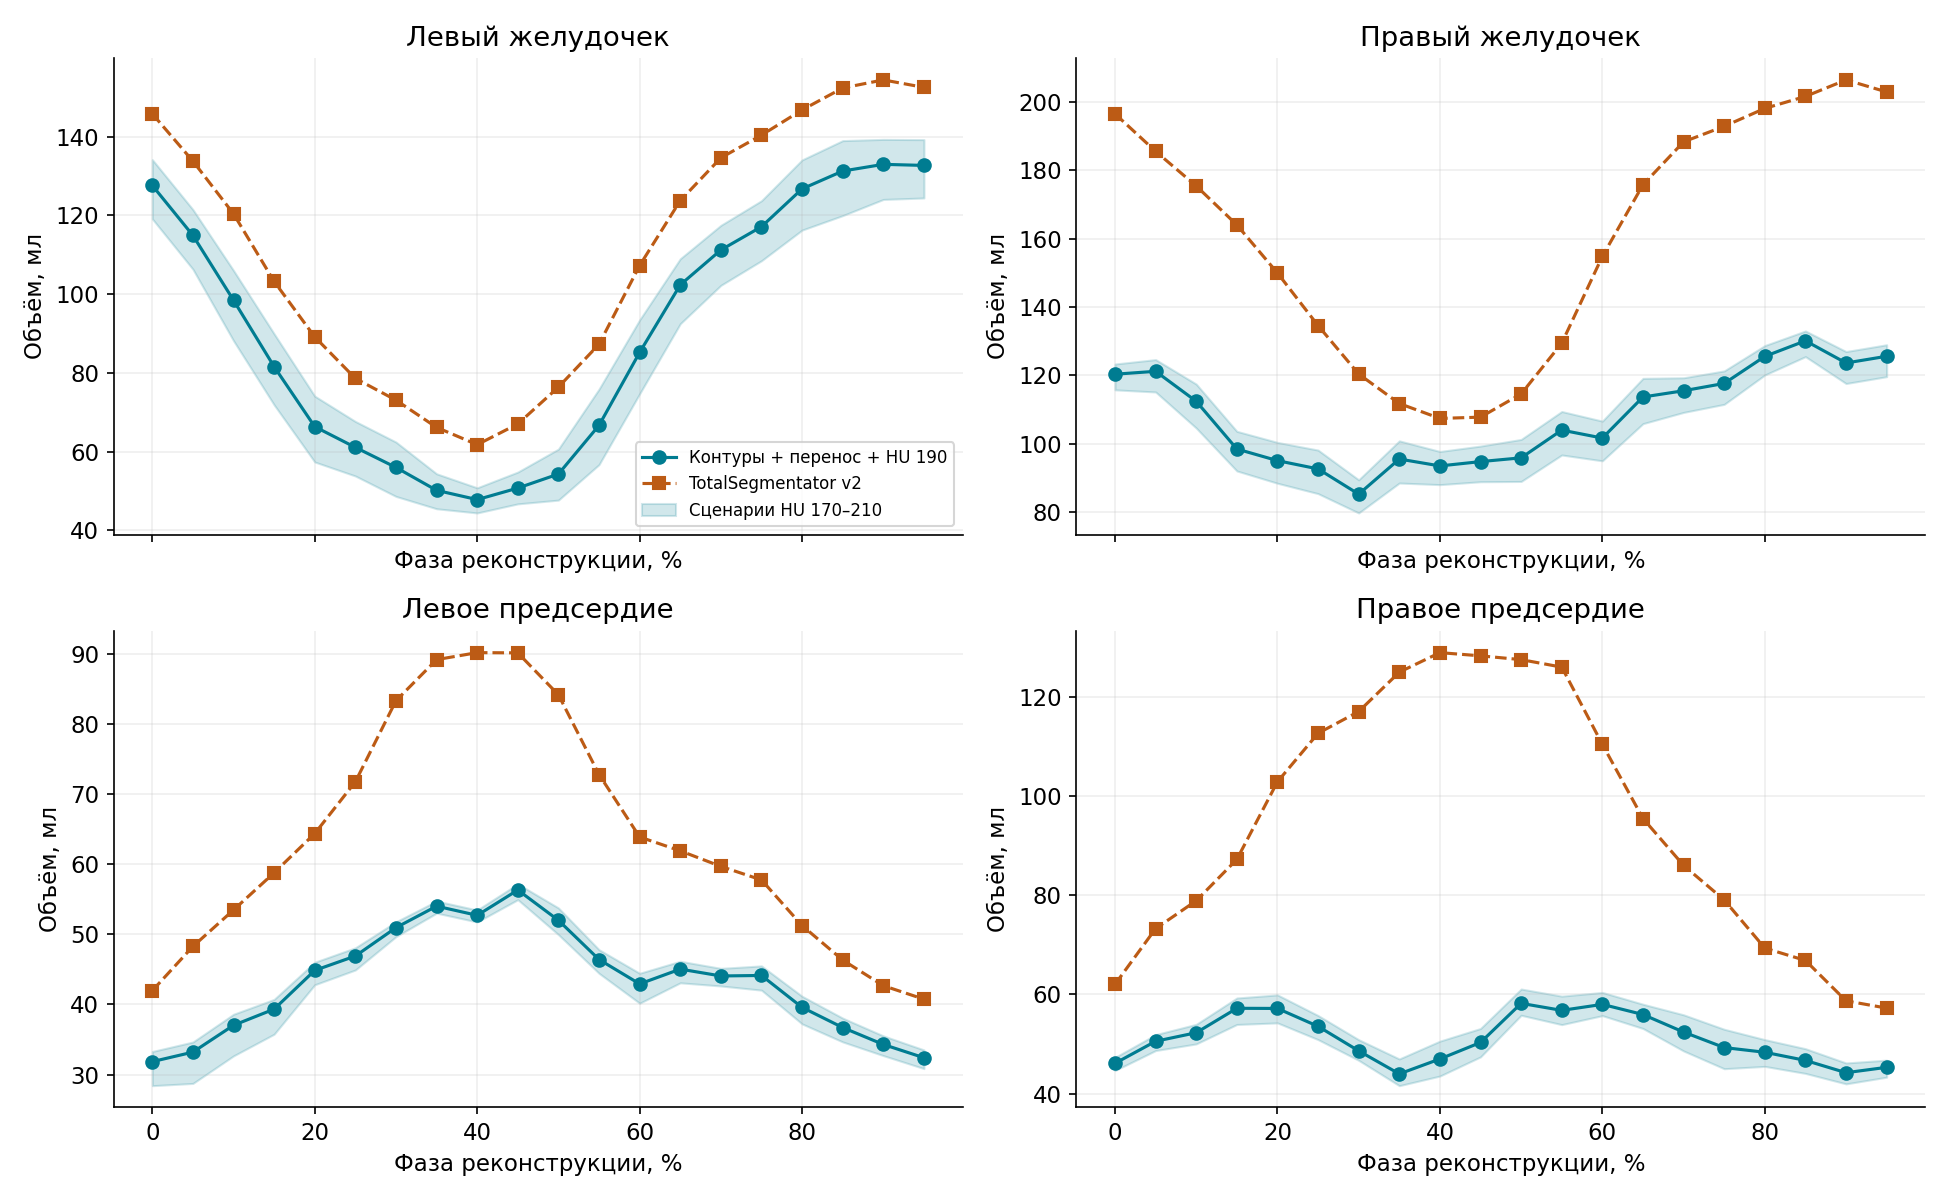

Рисунок 1. Абсолютные объёмы четырёх камер на 20 фазах. Полоса показывает размах результатов трёх пороговых сценариев; она не включает неопределённость клапанных границ и ошибки переноса.

Кривые позволяют разделить два вопроса: совпадают ли сами объёмы и воспроизводится ли их изменение. Различие начальных уровней особенно заметно для ПЖ. Его нельзя устранить выбором другого нуля без проверки того, какие анатомические области дают добавочный объём. Узкая полоса пороговых сценариев также не доказывает точность: одинаково обрезанная поисковая область останется неполной при всех трёх порогах.

### 5.2. Изменения относительно исходной фазы

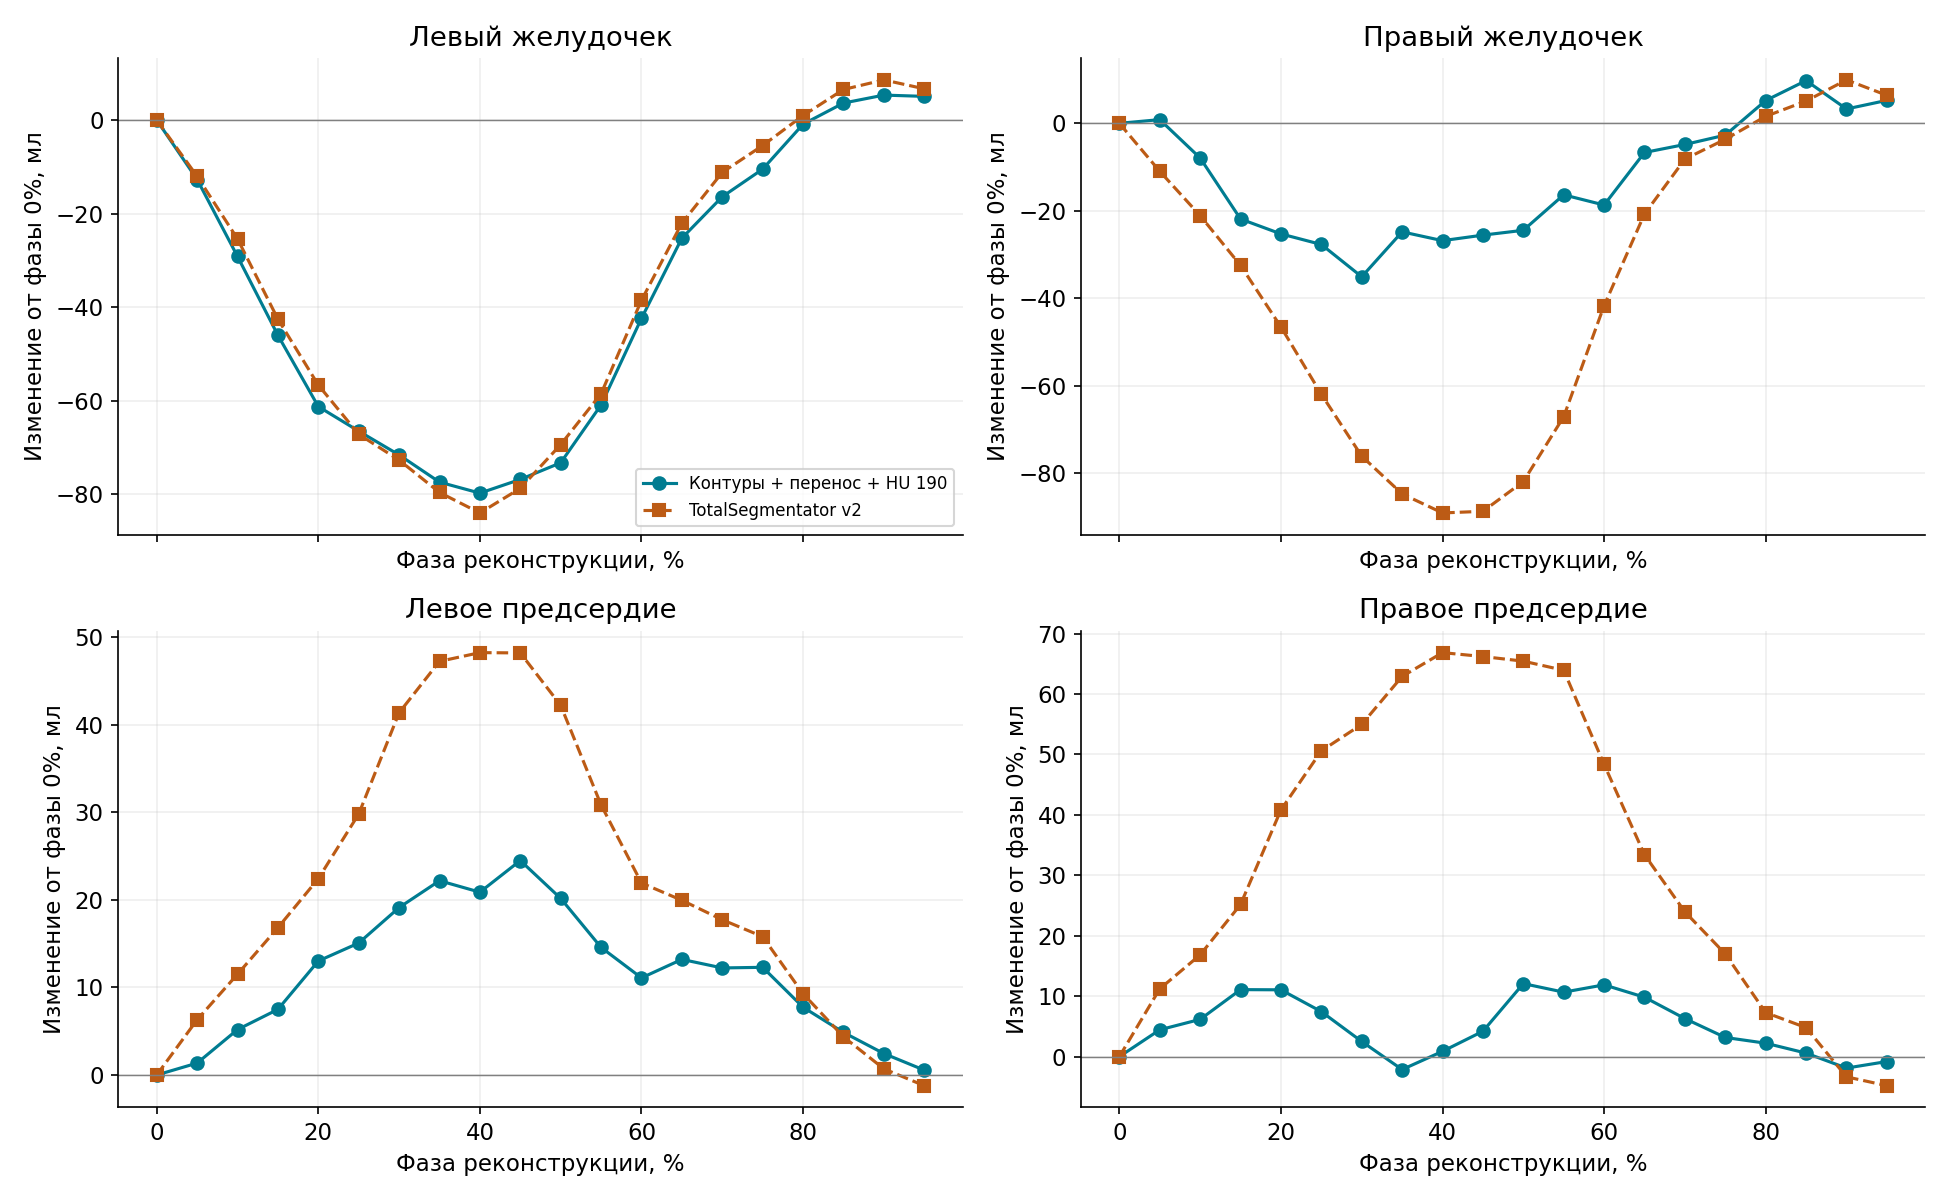

Рисунок 2. Изменения объёмов относительно фазы 0%. Для каждого способа вычтен его собственный исходный объём; график не представляет ударный объём.

| Камера | Фаза | Изменение кандидата, мл | Изменение TS, мл | Различие изменений, мл |
|---|---:|---:|---:|---:|
| Левый желудочек | 25% | -66.54 | -67.22 | -0.68 |
| Левый желудочек | 50% | -73.31 | -69.42 | +3.89 |
| Левый желудочек | 75% | -10.48 | -5.43 | +5.05 |
| Правый желудочек | 25% | -27.71 | -61.95 | -34.24 |
| Правый желудочек | 50% | -24.46 | -81.93 | -57.46 |
| Правый желудочек | 75% | -2.70 | -3.64 | -0.94 |
| Левое предсердие | 25% | +15.07 | +29.80 | +14.73 |
| Левое предсердие | 50% | +20.17 | +42.21 | +22.05 |
| Левое предсердие | 75% | +12.30 | +15.80 | +3.50 |
| Правое предсердие | 25% | +7.45 | +50.59 | +43.14 |
| Правое предсердие | 50% | +12.08 | +65.43 | +53.34 |
| Правое предсердие | 75% | +3.17 | +16.99 | +13.82 |

На фазе 50% кандидатный объём ЛЖ уменьшается на 73.31 мл, а результат TotalSegmentator — на 69.42 мл. Разность этих изменений составляет +3.89 мл. Таким образом, близость динамики ЛЖ на этой фазе сочетается с различием абсолютных уровней.

Для ПЖ на той же фазе изменения составляют -24.46 и -81.93 мл. Расхождение значительно больше, чем для ЛЖ. Его величина не позволяет считать оба способа взаимозаменяемыми, но не указывает, какой из них анатомически верен. Необходимо проверить разделение ПЖ и ПП и полноту выходного тракта.

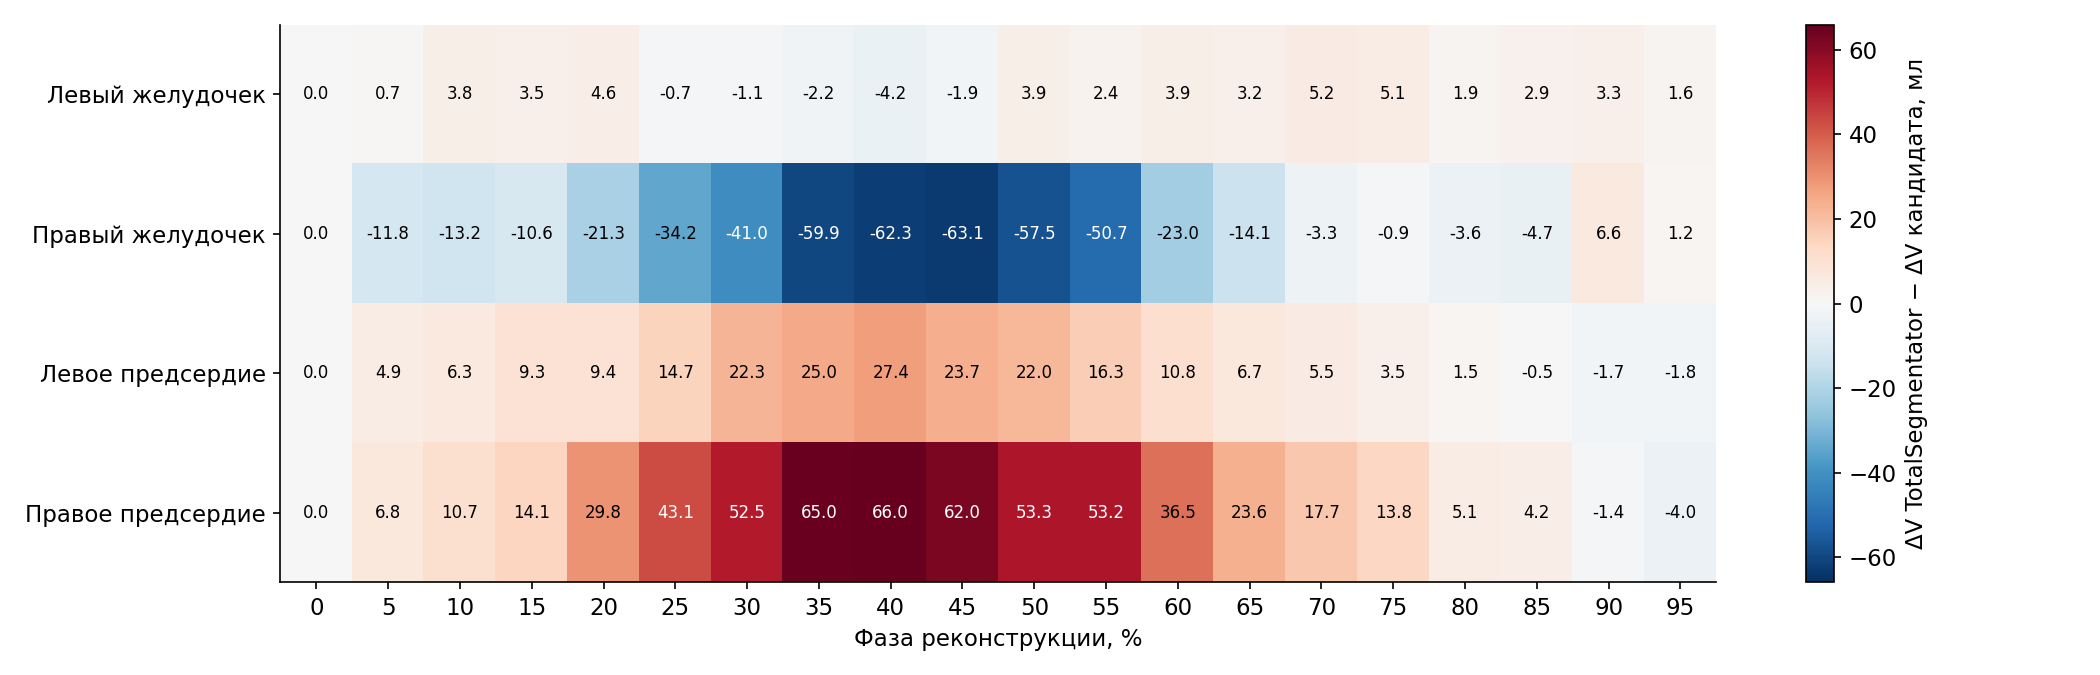

Рисунок 3. Различия изменений объёма: TotalSegmentator минус кандидат. Красный цвет — положительная разность, синий — отрицательная; общий масштаб в миллилитрах одинаков для всех камер.

Карта показывает фазы и камеры, на которых различие методов наиболее выражено. Нулевая первая колонка следует из определения изменения относительно исходной фазы и не является результатом валидации. Для остальных колонок малое значение означает согласованность конкретной разности объёмов; крупные несовпадения границ могут при этом частично компенсироваться.

| Камера | Среднее абсолютное расхождение изменений, мл | Максимум, мл | Фаза максимума |
|---|---:|---:|---:|
| Левый желудочек | 2.94 | 5.21 | 70% |
| Правый желудочек | 25.43 | 63.15 | 45% |
| Левое предсердие | 11.24 | 27.36 | 40% |
| Правое предсердие | 29.62 | 65.96 | 40% |

В таблице использованы все 19 последующих фаз; исходная фаза исключена, поскольку её разность тождественно равна нулю. Среднее рассчитано по модулям расхождений, чтобы положительные и отрицательные значения не компенсировались. Эти показатели суммируют несогласованность способов в одной серии и не являются оценкой ошибки относительно истинного объёма.

### 5.3. Чувствительность к приближённой границе камер

| Камера | Смещение границы −3 мм, мл | Без смещения, мл | Смещение +3 мм, мл |
|---|---:|---:|---:|
| Левый желудочек | 123.07 | 127.64 | 131.43 |
| Правый желудочек | 120.33 | 120.33 | 120.33 |
| Левое предсердие | 33.82 | 31.85 | 29.77 |
| Правое предсердие | 46.12 | 46.12 | 46.12 |

На исходной фазе дополнительно рассмотрен сдвиг параметра разделяющей границы на ±3 мм при неизменном пороге 190 HU. Для ЛЖ и ЛП эти сценарии заметно меняют объёмы. Для правых камер значения практически не меняются, поскольку правило действует только в пересечении их заданных поисковых областей. Такой нулевой отклик характеризует ограничение текущей реализации пробы; он не доказывает точность трёхстворчатой границы. Сценарии исходной фазы не являются доверительными интервалами и не охватывают неопределённость динамики клапанного кольца.

### 5.4. Зависимость результата от способа переноса

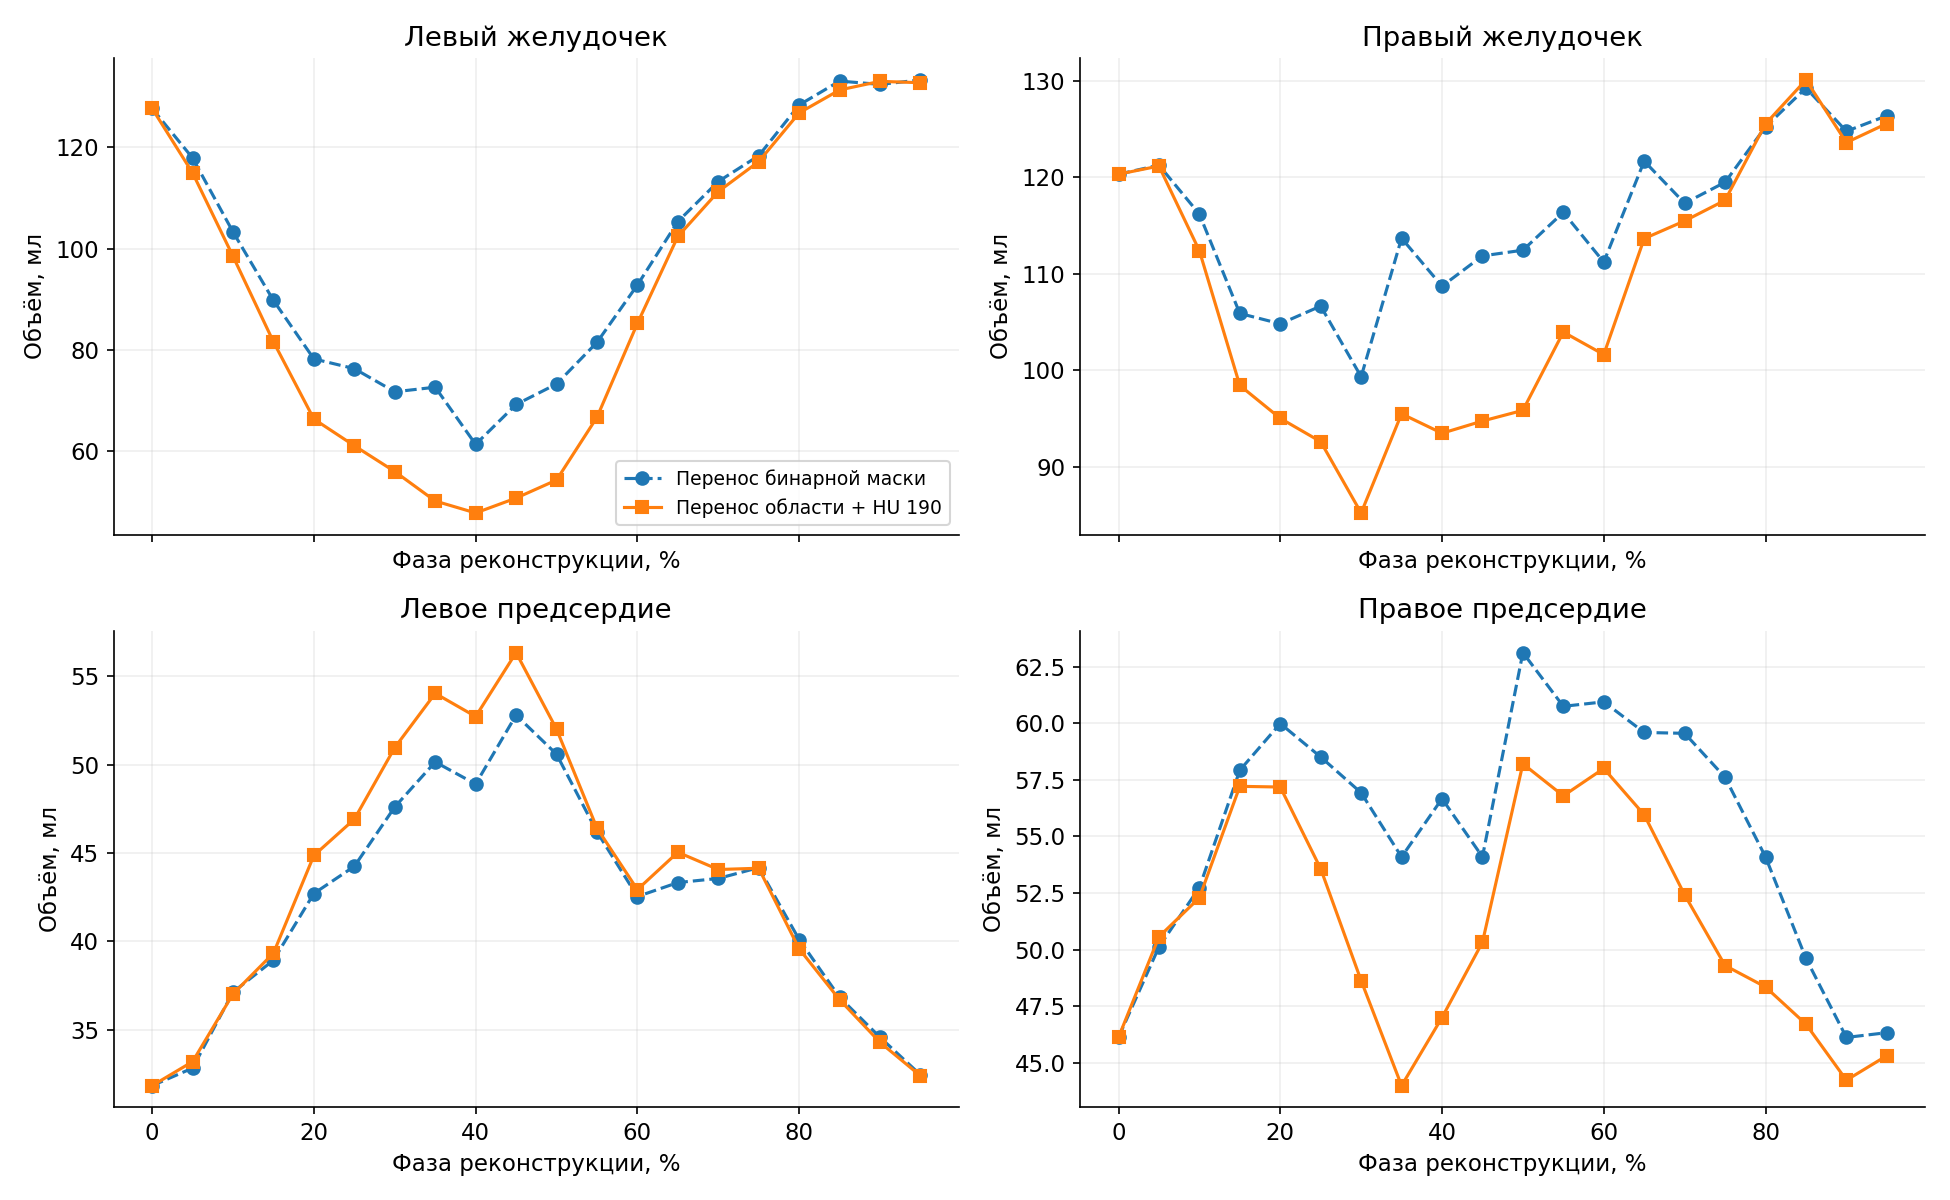

Рисунок 4. Перенос готовой бинарной маски и повторное выделение контрастной крови в перенесённой поисковой области. Оба варианта используют одно поле деформации КТ.

На фазе 50% объём ЛЖ при переносе готовой маски равен 73.27 мл, а после выделения крови в целевой КТ — 54.32 мл. Различие составляет 18.94 мл. Оно получено на одном изображении и поэтому характеризует зависимость оценки от алгоритма обработки, а не дополнительное физиологическое сокращение.

Пороговое выделение удаляет часть низкоинтенсивных участков, однако не исправляет ошибочное отнесение яркого участка к другой камере. Приближённая клапанная граница и ошибка поля деформации сохраняются. Близость одного из вариантов к TotalSegmentator не является достаточным основанием для его выбора.

### 5.5. Пространственные причины расхождений ПЖ

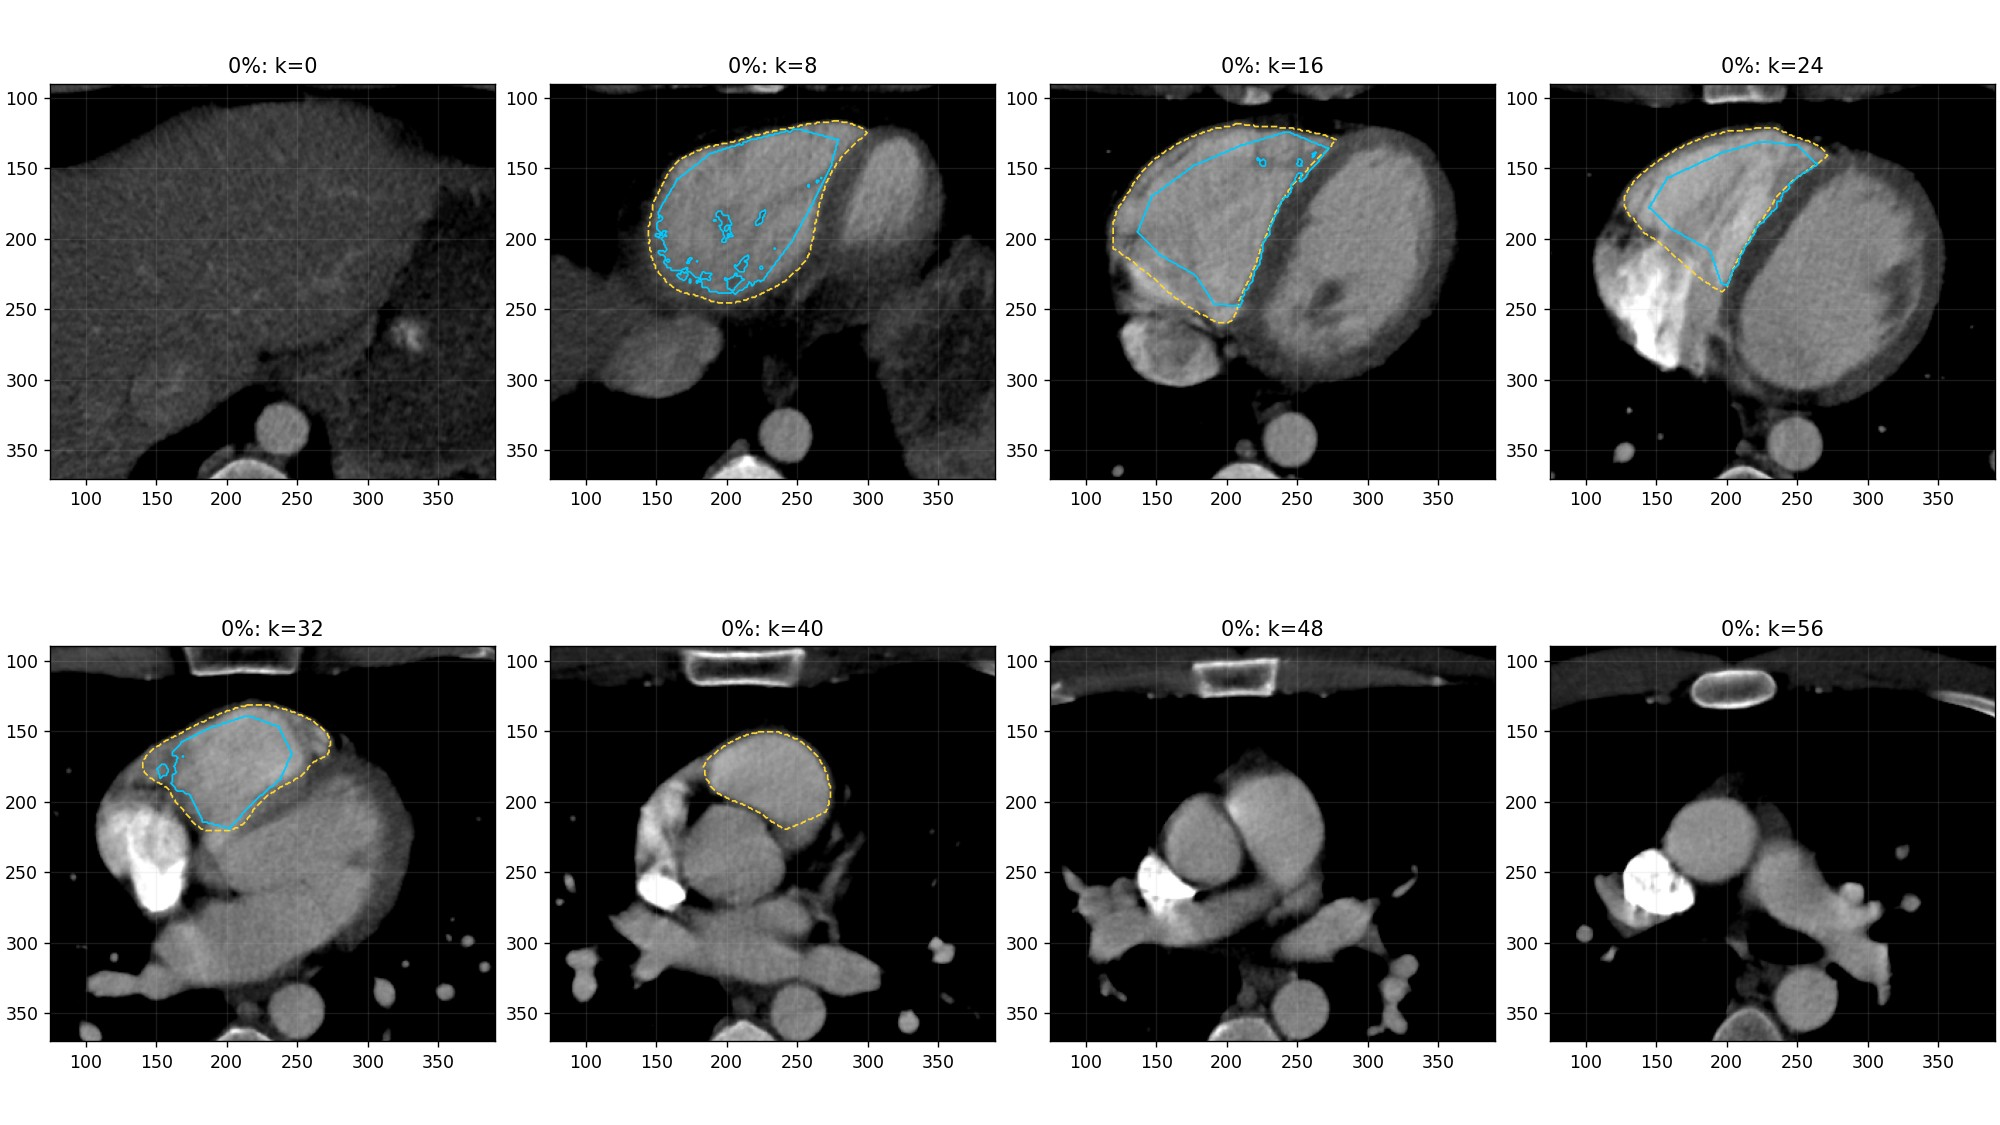

Рисунок 5. ПЖ на исходной фазе: кандидатный контур — голубой сплошной, TotalSegmentator — жёлтый пунктирный. Показаны различия наружного охвата и верхней протяжённости.

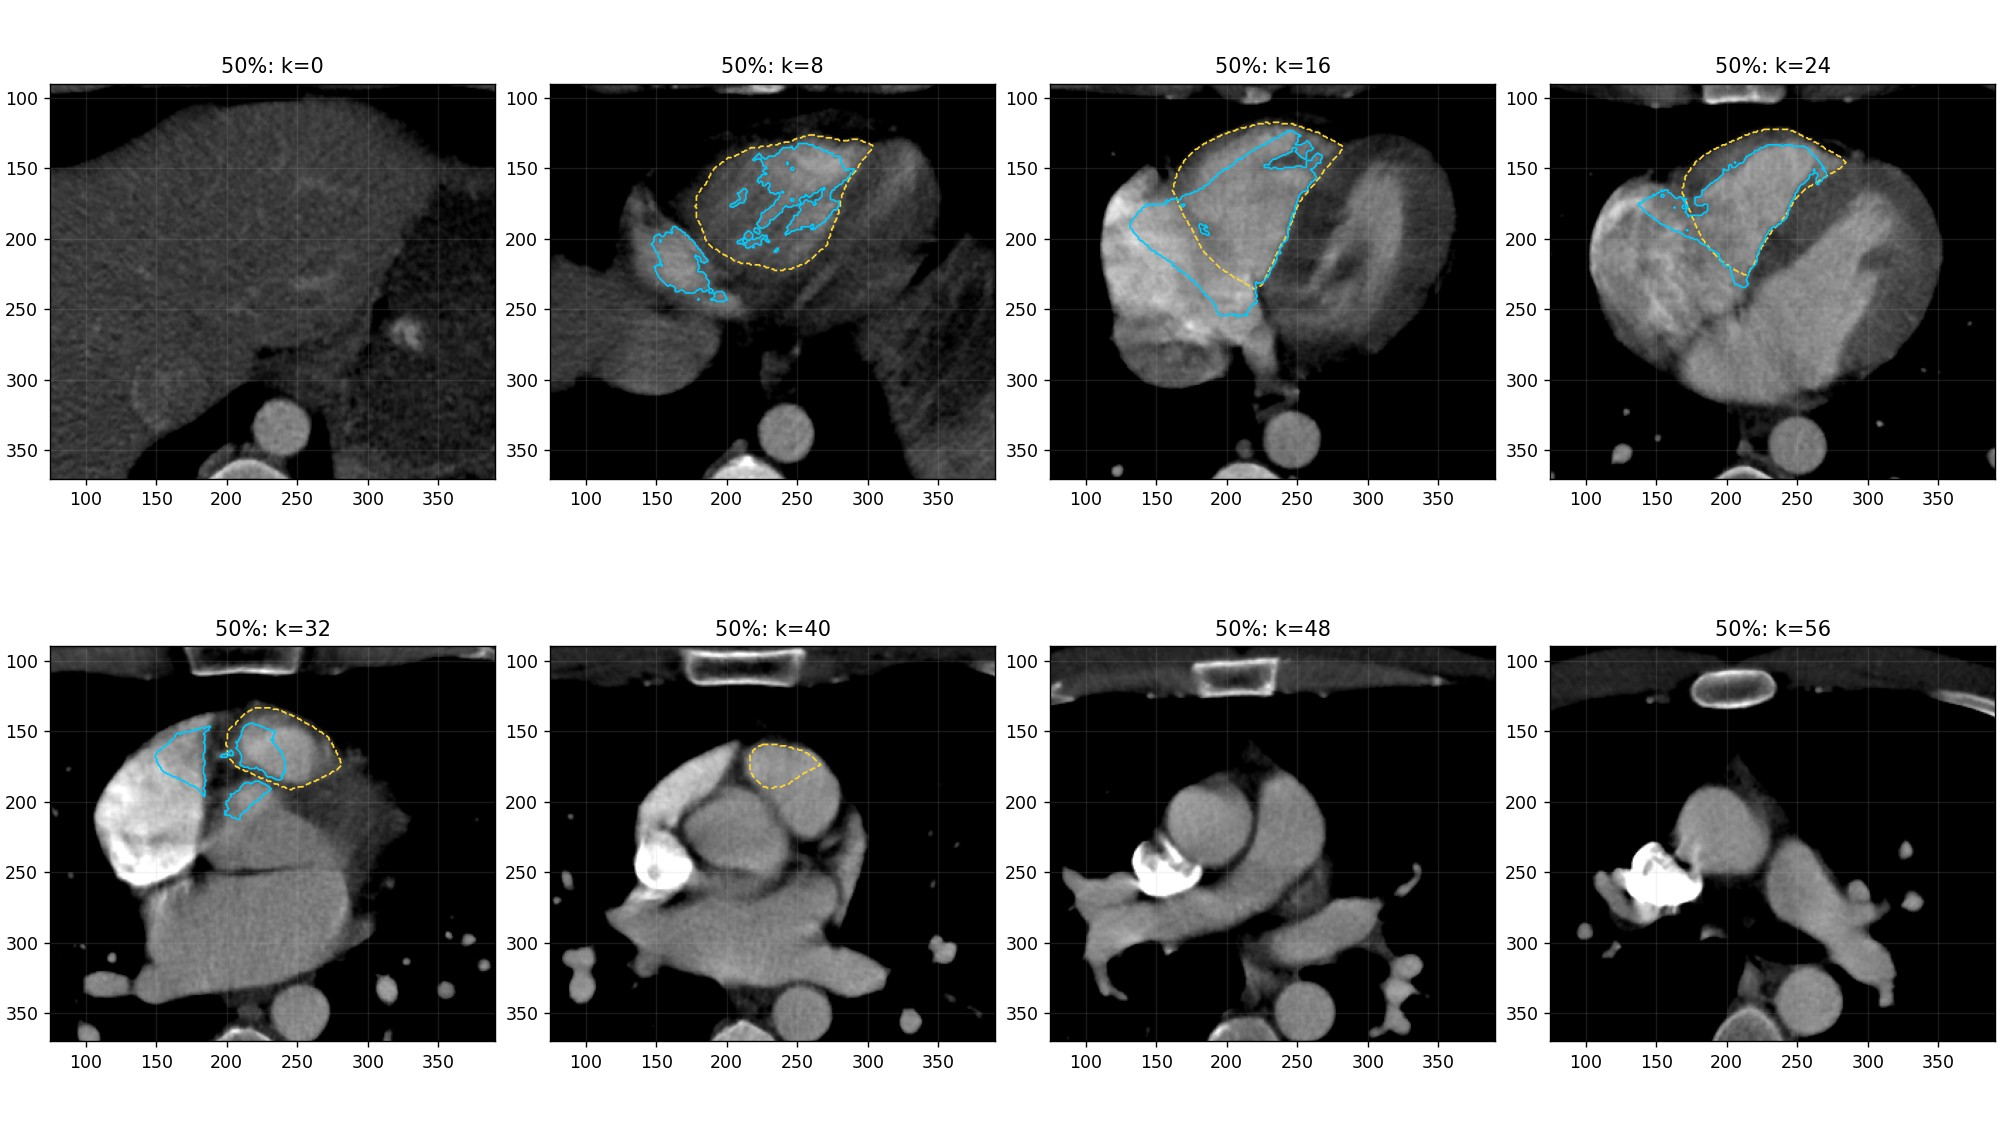

Рисунок 6. ПЖ на фазе 50% при тех же обозначениях. Расхождения включают участки около границы предсердия и выходного тракта; правильность их принадлежности ещё не установлена.

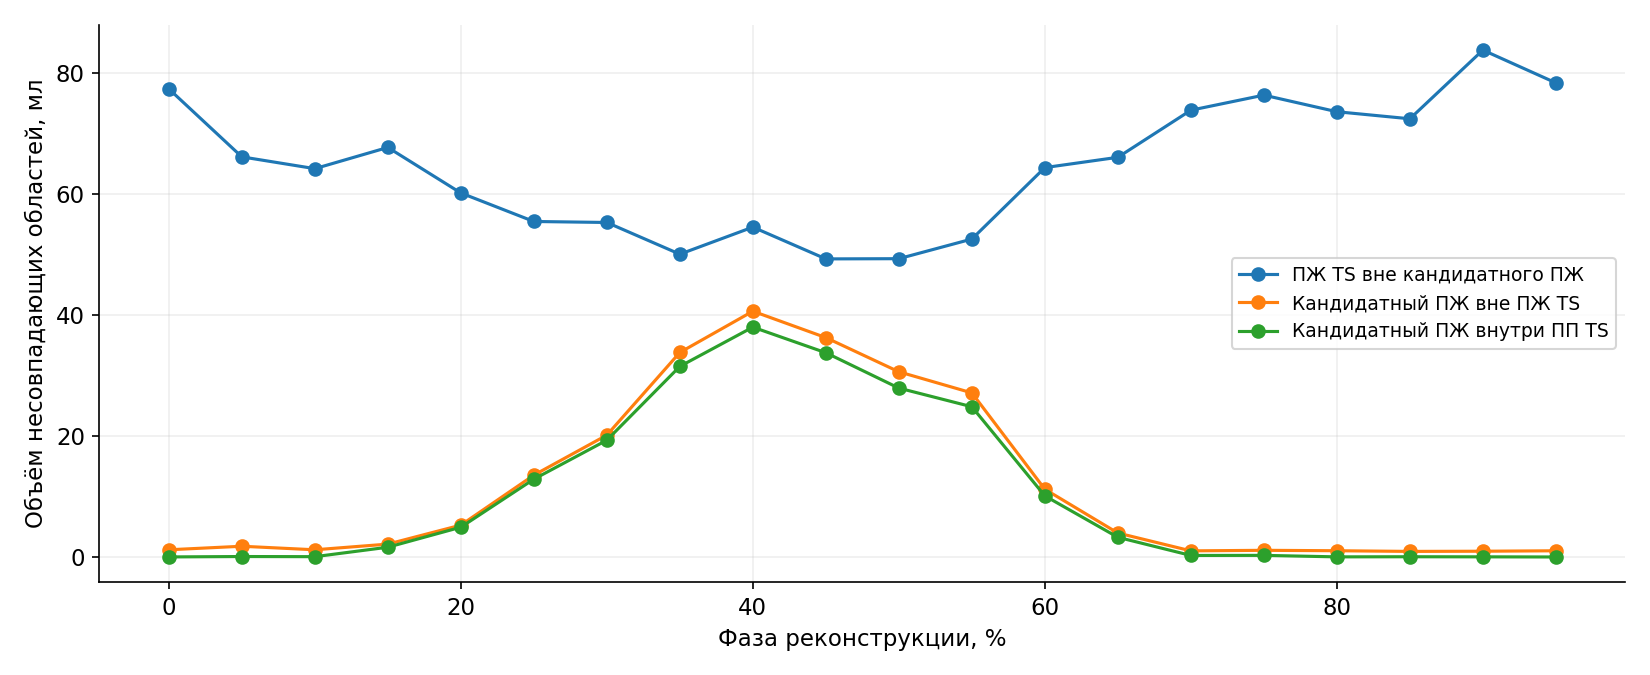

Рисунок 7. Объёмы несовпадающих областей ПЖ. Пересечение кандидатного ПЖ с автоматическим ПП показывает конфликт меток; оно не устанавливает истинную анатомическую принадлежность.

Наибольший конфликт меток ПЖ и ПП обнаружен на фазе 40%: 37.98 мл кандидатного ПЖ попадает в область, которую TotalSegmentator относит к ПП. Эта величина показывает, что расхождение касается не только положения наружного контура, но и разделения камер. Само пересечение не устанавливает, какой способ верен; оно задаёт конкретную область для повторного анатомического просмотра.

В исходной фазе кандидатный ПЖ заканчивается ниже автоматического. На фазе 50% дополнительно видны различия в яркой области около правого предсердия. Эти наблюдения согласуются с недостатками исходной границы и её переноса. Поэтому большое расхождение динамики ПЖ нельзя целиком приписывать TotalSegmentator. Для решения нужны разметка клапанного кольца и прослеживание выходного тракта в согласованных продольных и поперечных плоскостях.

### 5.6. Наружная область и ткань стенки

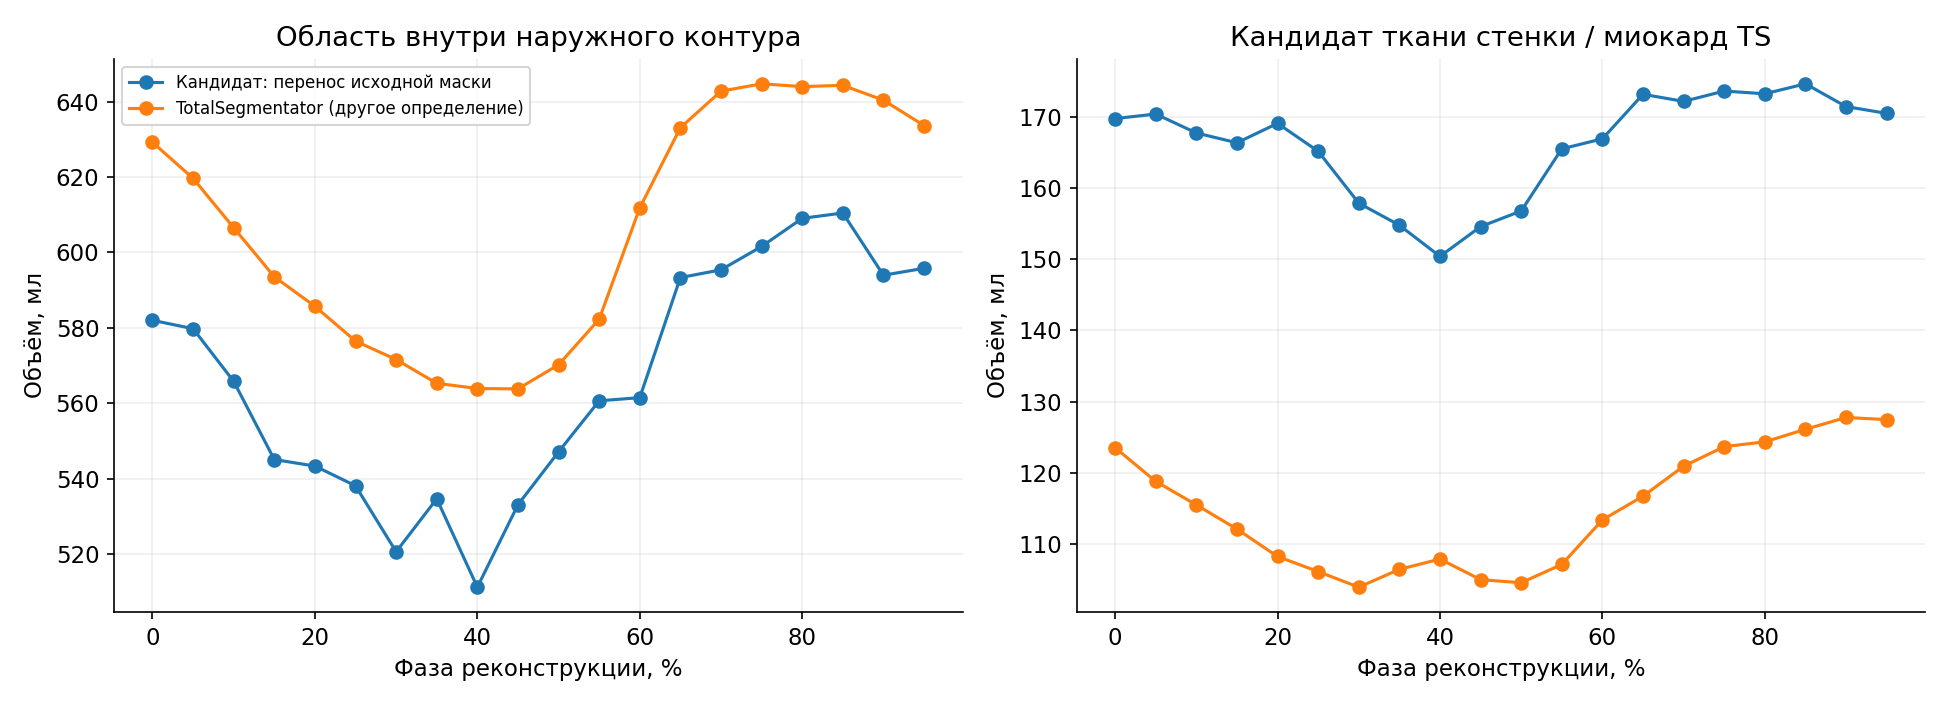

Рисунок 8. Динамика области внутри наружного контура и кандидата ткани стенки в сравнении с соответствующими выходами TotalSegmentator. Определения сопоставляемых областей различаются; разности не являются ошибками миокардиальной сегментации.

Сохранённые маски позволяют просматривать внешнюю геометрию и отделять полости от окружающего остатка. Однако верхнее отсечение наружного контура и низкая тканевая специфичность порогового остатка не позволяют считать задачу сегментации миокарда завершённой. Даже плавная кривая объёма не устраняет эти ограничения. Требуются самостоятельная наружная граница, согласованные сечения сосудов и проверка того, что остаётся после исключения крови.

### 5.7. Техническая проверка деформации

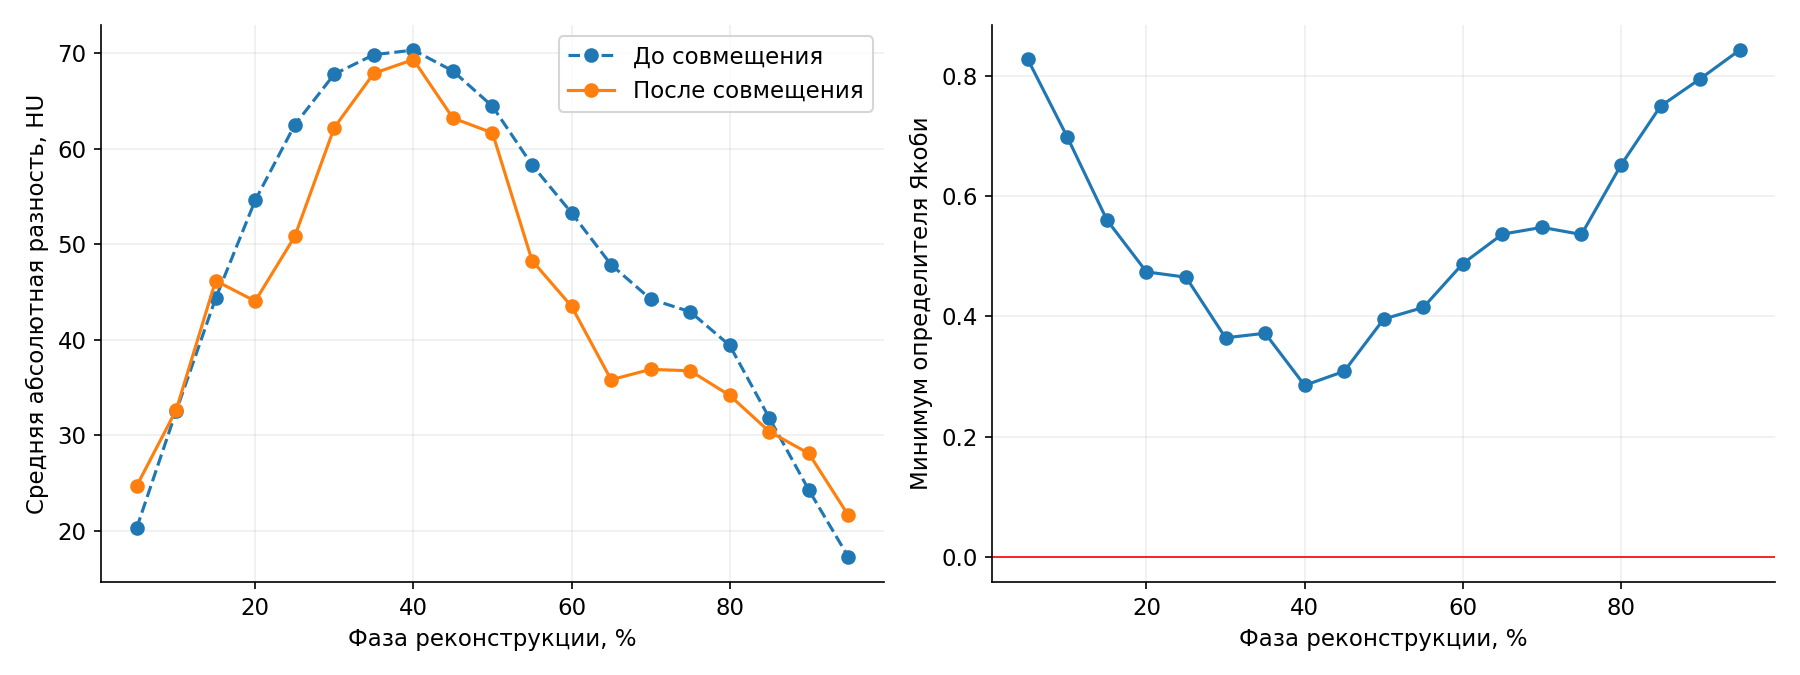

Рисунок 9. Средняя абсолютная разность интенсивностей КТ до и после совмещения и минимум определителя Якоби на расчётной сетке. Фаза 0% исключена, поскольку для неё преобразование тождественно.

Средняя абсолютная разность интенсивностей уменьшилась в 14 из 19 сопоставлений. Минимальное зарегистрированное значение определителя Якоби составляет 0.285; доля неположительных значений на проверенной сетке равна нулю. Это подтверждает отсутствие обнаруженных локальных инверсий на этой сетке. Проверка не исключает ошибок анатомического соответствия и не доказывает положительность во всех точках непрерывного поля.

В 14 сопоставлениях зарегистрировано достижение лимита итераций. Завершение алгоритма поэтому нельзя трактовать как доказанную оптимизационную сходимость. Кроме того, при совмещении оптимизировался критерий взаимной информации, тогда как средняя абсолютная разность служит дополнительным диагностическим показателем. Их изменения не обязаны совпадать.

## 6. Ограничения и выводы

Расчёт даёт воспроизводимое сравнение 20 фаз одной серии. Он показывает, что согласованность изменений объёма может быть существенно лучше согласованности абсолютных объёмов. На опорных фазах это наблюдается для ЛЖ. Для ПЖ и предсердий различия намного больше и требуют локальной анатомической проверки.

Главное ограничение относится к референсу: исходные контуры камер и наружной области ещё не приняты, а остальные фазы получены переносом. Неопределённость клапанных сечений, выходных трактов и устьев сосудов не охвачена тремя пороговыми сценариями. Отсутствуют повторная независимая разметка и количественная оценка воспроизводимости границ. На имеющихся результатах нельзя установить точность TotalSegmentator, выбрать достоверную оценку ударного объёма или подтвердить пригодность этих масок для замещения сердца эквивалентной сферой.

**Практический вывод:** готов полный вычислительный набор кандидатов и сравнение динамики; проверенный референс всего сердца пока не готов. Следующий приоритет — анатомические границы ПЖ и предсердий, затем наружная граница и миокард. Увеличение числа фаз или подбор порога без исправления этих границ не решит обнаруженную проблему.

## 7. Дальнейшая анатомическая проверка

1. На исходной фазе определить митральное и трёхстворчатое кольца, аортальный и лёгочный клапаны в нескольких согласованных плоскостях. Сохранить координаты, правило отсечения и неоднозначные участки. Отдельно проверить устья вен и ушки предсердий.
2. Исправить исходные границы ПЖ, предсердий и наружной области по этой анатомической разметке. Зафиксировать, что после настоящего сравнения разметчик уже видел результат TotalSegmentator; прежний вариант сохранить для истории.
3. На фазах 0, 25, 50 и 75% проверить каждую камеру на всём протяжении, затем просмотреть оставшиеся фазы. Исправления выполнять по целевой КТ, а не подгонять к форме автоматической кривой.
4. Получить независимую повторную разметку хотя бы опорных фаз без показа автоматических контуров. Сопоставить различия разметчиков и их влияние на межфазные изменения объёма.
5. После принятия анатомических границ повторить сравнение по объёму и поверхности. Только при отдельно установленных конечной диастоле и конечной систоле оценивать влияние расхождений на ударный объём и фракцию выброса.

## 8. Сохранённые данные и воспроизводимость

Сохранены маски камер для трёх порогов на 20 фазах, поля деформации, исходные спецификации контуров, кандидатные маски наружной области и стенки, контрольные суммы и таблицы объёмов. Для четырёх опорных фаз подготовлены редактируемые проекты Slicer. Исходные КТ и массивы масок хранятся локально; в научный отчёт включены обезличенные иллюстрации и агрегаты.

Сравнение рассчитывает модуль `compare_authored_cardiac_volumes.py`; сборку входов и диагностических рисунков выполняет `build_old_dynamic_comparison.py`. Перенос и пороговое уточнение доступны через `transport_old_cardiac_candidates.py` и `refine_old_cardiac_candidates.py`. Результаты текущего прогона связаны с зафиксированными версиями локальных скриптов через контрольные суммы. Генератор `build_old_dynamic_report.py` формирует этот ноутбук и HTML по рассчитанным данным без повторной сегментации.

Ноутбук содержит сохранённое исследовательское представление. Следующая ячейка позволяет повторить проверку и сравнение при наличии локального набора; она создаёт новый каталог и не заменяет исходные маски. HTML содержит только читательское представление, без исходного кода.

In [ ]:
from pathlib import Path
import os
from build_old_dynamic_comparison import assemble
root = Path(os.environ["OLD_REFERENCE_ROOT"])
# Укажите новый каталог: существующий результат не перезаписывается.
new_output = root / "whole_heart_comparison_repeat"
summary = assemble(root, new_output, expected=20)
print(summary["status"], summary["phase_count"])
